<a href="https://colab.research.google.com/github/gustavo159753/Analise-de-dados/blob/main/topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Criando o banco de dados

##Matriz

In [83]:
elementos = ['Palio', 'HB20', 'Corolla']
criterios = ['Consumo (Km/L)', 'Conforto (0 - 10)', 'Preço (R$)', 'Reputação (0-10)']
palio = [15, 6, 25000, 7]
hb20 = [12, 7, 35000, 7]
corolla = [10, 9, 55000, 8]
pesos_criterios = [0.3, 0.05, 0.6, 0.05]

print("Critérios avaliados:", criterios)

Critérios avaliados: ['Consumo (Km/L)', 'Conforto (0 - 10)', 'Preço (R$)', 'Reputação (0-10)']


In [62]:
matriz_d = np.array([palio, hb20, corolla])
matriz_d

array([[   15,     6, 25000,     7],
       [   12,     7, 35000,     7],
       [   10,     9, 55000,     8]])

#Normalizando

In [84]:
import numpy as np
# normalizar: Valores do vetor vn / módulo da somatória dos vetores elevado ao quadrado. Ex: sqrt(12**2 + 15**2 + 18**2)

matriz_normalizada = np.zeros_like(matriz_d, dtype=float)

for j in range(matriz_d.shape[1]): # Iterar sobre as colunas
    coluna = matriz_d[:, j]
    norma = np.linalg.norm(coluna) # Calcular a norma L2 da coluna
    if norma != 0:
        matriz_normalizada[:, j] = coluna / norma
    else:
        matriz_normalizada[:, j] = 0 # Lidar com o caso em que a norma é zero para evitar divisão por zero

print("Matriz Normalizada:")
print(matriz_normalizada)

Matriz Normalizada:
[[0.69263564 0.46569032 0.35805744 0.54997194]
 [0.55410852 0.54330537 0.50128041 0.54997194]
 [0.4617571  0.69853547 0.78772636 0.62853936]]


#Adicionando o peso de cada critério

In [85]:
# MULTIPLICANDO CADA COLUNA PELO PESO DO CRITÉRIO
matrizR = matriz_normalizada * pesos_criterios

print("Matriz Ponderada (matrizR):")
print(matrizR)

Matriz Ponderada (matrizR):
[[0.20779069 0.02328452 0.21483446 0.0274986 ]
 [0.16623255 0.02716527 0.30076825 0.0274986 ]
 [0.13852713 0.03492677 0.47263582 0.03142697]]


#Determinando a solução ideal A+ e A-

In [65]:
tipos_criterios = ['custo', 'beneficio', 'custo', 'beneficio']
print("Classificação dos critérios:", tipos_criterios)

Classificação dos critérios: ['custo', 'beneficio', 'custo', 'beneficio']


In [86]:
a_plus = []

for j in range(matrizR.shape[1]): # Iterar sobre as colunas
    column = matrizR[:, j]
    criterion_type = tipos_criterios[j]

    if criterion_type == 'beneficio':
        a_plus.append(np.max(column))
    elif criterion_type == 'custo':
        a_plus.append(np.min(column))

a_plus = np.array(a_plus)

print("Solução Ideal Positiva (A+):")
print(a_plus)

Solução Ideal Positiva (A+):
[0.13852713 0.03492677 0.21483446 0.03142697]


In [87]:
a_minus = []

for j in range(matrizR.shape[1]): # Iterar sobre as colunas
    column = matrizR[:, j]
    criterion_type = tipos_criterios[j]

    if criterion_type == 'beneficio':
        a_minus.append(np.min(column))
    elif criterion_type == 'custo':
        a_minus.append(np.max(column))

a_minus = np.array(a_minus)

print("Solução Ideal Negativa (A-):")
print(a_minus)

Solução Ideal Negativa (A-):
[0.20779069 0.02328452 0.47263582 0.0274986 ]


#Calculando as distâncias Euclidianas

In [88]:
dist_a_plus = []

for i in range(matrizR.shape[0]): # Iterar sobre as linhas
    distance = np.linalg.norm(matrizR[i, :] - a_plus)
    dist_a_plus.append(distance)

dist_a_plus = np.array(dist_a_plus)

print("Distâncias Euclidianas para a Solução Ideal Positiva (A+):")
print(dist_a_plus)

Distâncias Euclidianas para a Solução Ideal Positiva (A+):
[0.07034498 0.09070766 0.25780135]


In [89]:
dist_a_minus = []

for i in range(matrizR.shape[0]): # Iterar sobre as linhas
    distance = np.linalg.norm(matrizR[i, :] - a_minus)
    dist_a_minus.append(distance)

dist_a_minus = np.array(dist_a_minus)

print("Distâncias Euclidianas para a Solução Ideal Negativa (A-):")
print(dist_a_minus)

Distâncias Euclidianas para a Solução Ideal Negativa (A-):
[0.25780135 0.17686323 0.07034498]


In [70]:
# Cálculo das Distâncias Euclidianas
dist_a_plus = []
dist_a_minus = []

for i in range(matrizR.shape[0]):
    # Distância para a solução ideal positiva (di+)
    d_plus = np.sqrt(np.sum((a_plus - matrizR[i, :])**2))
    dist_a_plus.append(d_plus)

    # Distância para a solução ideal negativa (di-)
    d_minus = np.sqrt(np.sum((a_minus - matrizR[i, :])**2))
    dist_a_minus.append(d_minus)

dist_a_plus = np.array(dist_a_plus)
dist_a_minus = np.array(dist_a_minus)

print("Distâncias para a Solução Ideal Positiva (di+):")
for i, d in enumerate(dist_a_plus):
    print(f"{elementos[i]}: {d:.4f}")

print("\nDistâncias para a Solução Ideal Negativa (di-):")
for i, d in enumerate(dist_a_minus):
    print(f"{elementos[i]}: {d:.4f}")

Distâncias para a Solução Ideal Positiva (di+):
Palio: 0.0703
HB20: 0.0907
Corolla: 0.2578

Distâncias para a Solução Ideal Negativa (di-):
Palio: 0.2578
HB20: 0.1769
Corolla: 0.0703


# Cálculo da Proximidade Relativa (C_i / Ksi)

In [71]:
closeness = []

for i in range(len(dist_a_plus)):
    # Nota: A fórmula padrão do TOPSIS é di- / (di+ + di-)
    valor_ksi = dist_a_minus[i] / (dist_a_plus[i] + dist_a_minus[i])
    closeness.append(valor_ksi)

closeness = np.array(closeness)

# Criando o DataFrame para o Ranking
ranking_df = pd.DataFrame({
    'Alternativa': elementos,
    'di+': dist_a_plus,
    'di-': dist_a_minus,
    'Ksi (C_i)': closeness
})

# Ordenando do melhor para o pior (maior Ksi é melhor)
ranking_df = ranking_df.sort_values(by='Ksi (C_i)', ascending=False)

print("Ranking Final das Alternativas:")
display(ranking_df)

Ranking Final das Alternativas:


,Alternativa,di+,di-,Ksi (C_i)
0,Palio,0.070345,0.257801,0.785629
1,HB20,0.090708,0.176863,0.660996
2,Corolla,0.257801,0.070345,0.214371


#Resultados da Análise de Sensibilidade (Score Ksi)

In [90]:
def run_topsis(weights):
    # 1. Matriz de Decisão Normalizada Ponderada
    matrix_r = matriz_normalizada * weights

    # 2. Determinar Soluções Ideais Positivas (A+) e Negativas (A-)
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))

    a_plus = np.array(a_plus)
    a_minus = np.array(a_minus)

    # 3. Calcular Distâncias Euclidianas
    dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
    dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))

    # 4. Calcular Proximidade Relativa (Ksi)
    ksi = dist_m / (dist_p + dist_m)
    return ksi

# Definir Cenários
scenarios = {
    'Base': [0.3, 0.05, 0.6, 0.05], # Original
    'Foco Conforto': [0.1, 0.7, 0.1, 0.1],
    'Preço Reduzido': [0.4, 0.1, 0.1, 0.4],
    'Equilibrado': [0.25, 0.25, 0.25, 0.25]
}

results = {}
for name, w in scenarios.items():
    results[name] = run_topsis(w)

# Criar DataFrame
sensitivity_df = pd.DataFrame(results, index=elementos)
print('Resultados da Análise de Sensibilidade (Score Ksi):')
print(sensitivity_df)

Resultados da Análise de Sensibilidade (Score Ksi):
             Base  Foco Conforto  Preço Reduzido  Equilibrado
Palio    0.785629       0.206797        0.299924     0.560300
HB20     0.660996       0.363456        0.543014     0.573527
Corolla  0.214371       0.793203        0.700076     0.439700


#Analise de Sensibilidade TOPSIS: Cenarios de Pesos

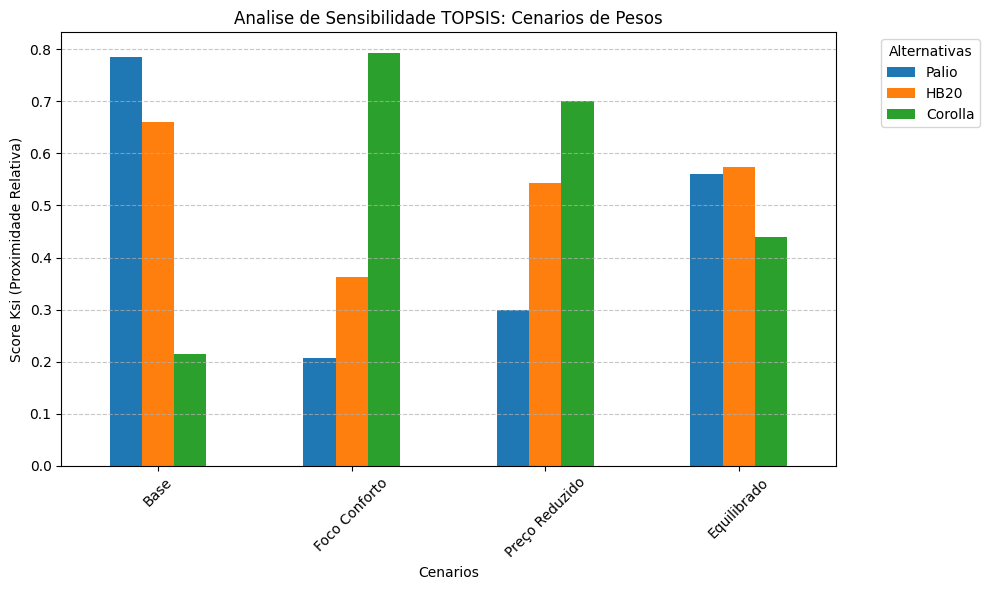

In [75]:
import matplotlib.pyplot as plt

sensitivity_df.T.plot(kind="bar", figsize=(10, 6))
plt.title("Analise de Sensibilidade TOPSIS: Cenarios de Pesos")
plt.xlabel("Cenarios")
plt.ylabel("Score Ksi (Proximidade Relativa)")
plt.legend(title="Alternativas", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#Sensibilidade do Ranking a Diferentes Metricas de Distancia

Comparativo de Multiplas Metricas de Distancia:


,Euclidiana (L2),Manhattan (L1),Minkowski (p=3),Chebyshev (L-inf)
Palio,0.785629,0.752407,0.787953,0.788227
HB20,0.660996,0.634220,0.665205,0.666667
Corolla,0.214371,0.247593,0.212047,0.211773


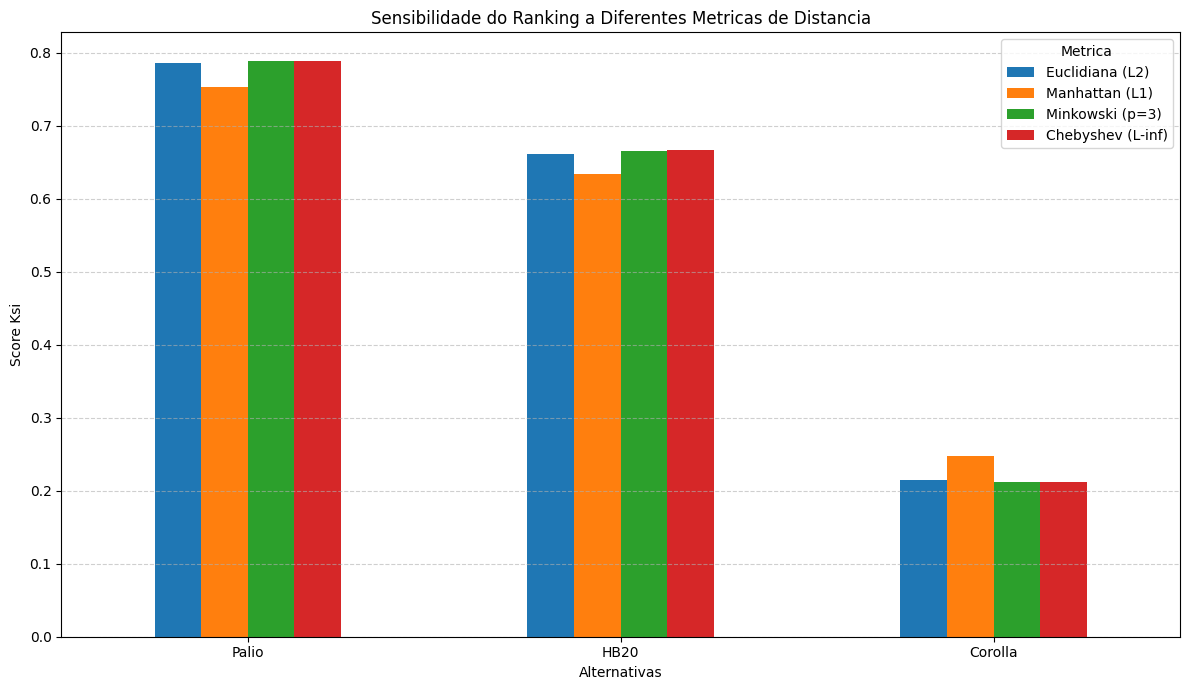

In [91]:
def run_topsis_metrics(weights, metric='L2', p_val=3):
    # 1. Matriz de Decisão Normalizada Ponderada
    matrix_r = matriz_normalizada * weights

    # 2. Determinar Soluções Ideais Positivas (A+) e Negativas (A-)
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))

    a_plus = np.array(a_plus)
    a_minus = np.array(a_minus)

    # 3. Calcular Distâncias baseadas na métrica selecionada
    if metric == 'L2':
        dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
        dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))
    elif metric == 'L1':
        dist_p = np.sum(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.sum(np.abs(matrix_r - a_minus), axis=1)
    elif metric == 'Minkowski':
        dist_p = np.sum(np.abs(matrix_r - a_plus)**p_val, axis=1)**(1/p_val)
        dist_m = np.sum(np.abs(matrix_r - a_minus)**p_val, axis=1)**(1/p_val)
    elif metric == 'Chebyshev':
        dist_p = np.max(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.max(np.abs(matrix_r - a_minus), axis=1)

    # 4. Calcular Proximidade Relativa (Ksi)
    ksi = dist_m / (dist_p + dist_m)
    return ksi

# Pesos Base
base_weights = [0.3, 0.05, 0.6, 0.05]

# Executar TOPSIS com múltiplas métricas
metrics_results = {
    'Euclidiana (L2)': run_topsis_metrics(base_weights, metric='L2'),
    'Manhattan (L1)': run_topsis_metrics(base_weights, metric='L1'),
    'Minkowski (p=3)': run_topsis_metrics(base_weights, metric='Minkowski'),
    'Chebyshev (L-inf)': run_topsis_metrics(base_weights, metric='Chebyshev')
}

comparison_metrics_df = pd.DataFrame(metrics_results, index=elementos)

print('Comparativo de Multiplas Metricas de Distancia:')
display(comparison_metrics_df)

# Visualização
comparison_metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Sensibilidade do Ranking a Diferentes Metricas de Distancia')
plt.xlabel('Alternativas')
plt.ylabel('Score Ksi')
plt.xticks(rotation=0)
plt.legend(title='Metrica', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Análise de Robustez

Frequência de Vitórias (%):
Palio      80.3
HB20       19.7
Corolla     0.0
Name: proportion, dtype: float64


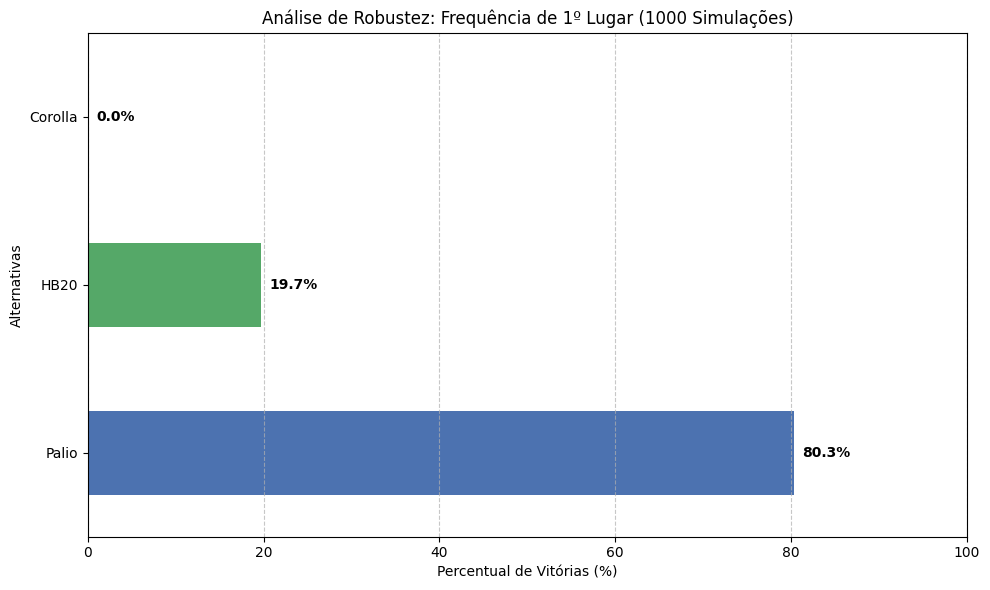

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definir semente para reprodutibilidade
np.random.seed(42)

# 2. Parâmetros da simulação
n_simulations = 1000
noise_std = 0.05
base_weights = [0.3, 0.05, 0.6, 0.05]
winners = []

# 3. Loop de Simulação
for _ in range(n_simulations):
    # Adicionar pequeno ruído Gaussiano à matriz normalizada
    noise = np.random.normal(0, noise_std, matriz_normalizada.shape)
    perturbed_matrix = np.clip(matriz_normalizada + noise, 0, 1) # Manter valores dentro de limites válidos

    def run_topsis_internal(matrix, weights):
        matrix_r = matrix * weights
        a_plus = []
        a_minus = []
        for j in range(matrix_r.shape[1]):
            col = matrix_r[:, j]
            if tipos_criterios[j] == 'beneficio':
                a_plus.append(np.max(col))
                a_minus.append(np.min(col))
            else:
                a_plus.append(np.min(col))
                a_minus.append(np.max(col))
        a_p, a_m = np.array(a_plus), np.array(a_minus)
        dist_p = np.sqrt(np.sum((matrix_r - a_p)**2, axis=1))
        dist_m = np.sqrt(np.sum((matrix_r - a_m)**2, axis=1))
        return dist_m / (dist_p + dist_m)

    # Calcular scores para esta iteração
    scores = run_topsis_internal(perturbed_matrix, base_weights)
    winners.append(elementos[np.argmax(scores)])

# 4. Calcular frequências
win_counts = pd.Series(winners).value_counts(normalize=True) * 100
for car in elementos:
    if car not in win_counts: win_counts[car] = 0.0
win_counts = win_counts.reindex(elementos)

print("Frequência de Vitórias (%):")
print(win_counts)

# 5. Visualização
plt.figure(figsize=(10, 6))
win_counts.plot(kind='barh', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Análise de Robustez: Frequência de 1º Lugar (1000 Simulações)')
plt.xlabel('Percentual de Vitórias (%)')
plt.ylabel('Alternativas')
plt.xlim(0, 100)
for i, v in enumerate(win_counts):
    plt.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Heatmap correlações de Pearson e Sperman

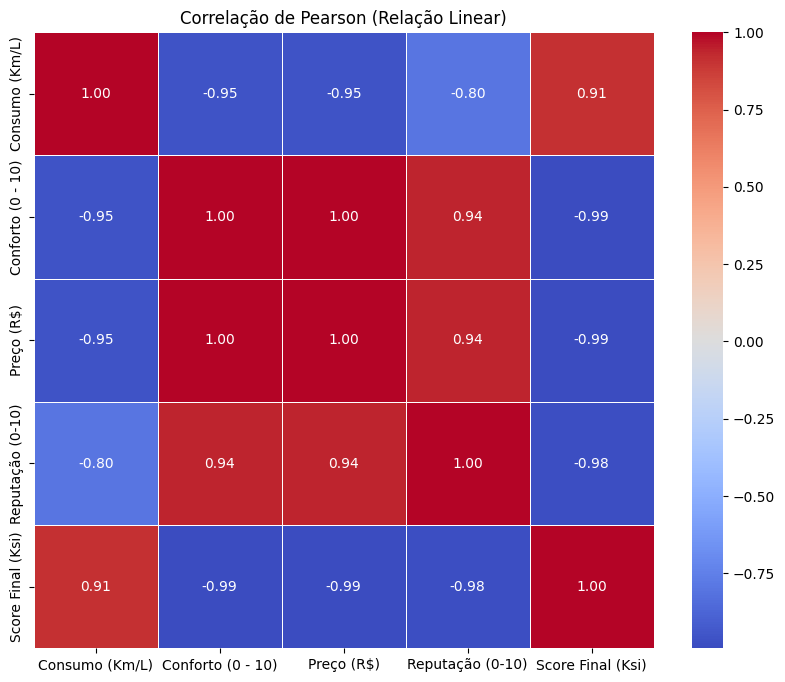

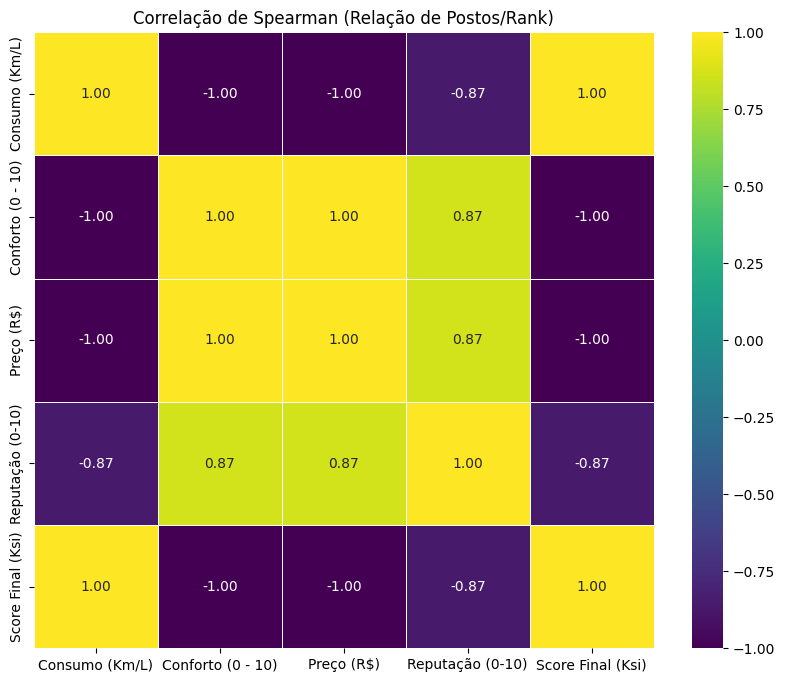

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Criar um DataFrame combinando critérios e o score final (Ksi)
corr_data = pd.DataFrame(matrizR, columns=criterios)
corr_data['Score Final (Ksi)'] = closeness

# 2. Calcular matrizes de correlação
corr_pearson = corr_data.corr(method='pearson')
corr_spearman = corr_data.corr(method='spearman')

# 3. Gerar Heatmap de Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlação de Pearson (Relação Linear)')
plt.show()

# 4. Gerar Heatmap de Spearman
plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Correlação de Spearman (Relação de Postos/Rank)')
plt.show()